# Double Quantum Dot

This notebook is used to run numerical simulations of a heterostructure hosting a double quantum dot in 2D, and 3D. The 2DHG is expected to form in the Ge layer (about 2nm below the surface). This is a sequential double quantum dot, i.e. a 1x2 array already.

## 0. Setup

### - Imports

Import the necessary libraries and packagaes to run nextnano simulations.

In [1]:
import os
import re
import sys
import importlib.metadata
from pathlib import Path
import numpy as np
import nextnanopy as nn
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

print("Python:", sys.version)
print("CWD:", os.getcwd())
print("nextnanopy version:", importlib.metadata.version("nextnanopy"))

REPO_ROOT = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit")
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import nextnano_analysis as nna
importlib.reload(nna)

Python: 3.11.13 (main, Jun  5 2025, 08:14:07) [Clang 14.0.6 ]
CWD: /Users/robertjovanov/code/qpu-design-automation-toolkit/notebooks/experiments
nextnanopy version: 1.0.3


<module 'nextnano_analysis' from '/Users/robertjovanov/code/qpu-design-automation-toolkit/src/nextnano_analysis.py'>

### - Input Config

Set here all the necessary configuration parameters for the simulation.

In [11]:
# path to (2D) simulation input file for a double QD device
INPUT_DOUBLE_DOT_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit"
                    "/configs/robert_inputs/double_qd/2d/"
                    "Double_Quantum_Dot_2D.in")
print("INPUT_SINGLE_DOT_2D exists:", INPUT_DOUBLE_DOT_2D.exists(), INPUT_DOUBLE_DOT_2D)

# path to (3D) simulation input file for double QD
INPUT_DOUBLE_DOT_3D = Path(
    "/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/robert_inputs/double_qd/3d/Double_Quantum_Dot_3D.in"
)
print("INPUT_DOUBLE_DOT_3D exists:", INPUT_DOUBLE_DOT_3D.exists(), INPUT_DOUBLE_DOT_3D)

INPUT_SINGLE_DOT_2D exists: True /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/robert_inputs/double_qd/2d/Double_Quantum_Dot_2D.in
INPUT_DOUBLE_DOT_3D exists: True /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/robert_inputs/double_qd/3d/Double_Quantum_Dot_3D.in


### - Helper functions

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle

def _find_unique(folder, patterns):
    folder = Path(folder)
    matches = []
    for pat in patterns:
        matches.extend(folder.glob(pat))
    matches = sorted(set(matches))
    if not matches:
        raise FileNotFoundError(
            f"No file found in {folder} matching any of: {patterns}"
        )
    if len(matches) > 1:
        print("Multiple matches found, using:", matches[0].name)
        print("All matches:", [m.name for m in matches])
    return matches[0]

def section_fld(folder, stem, section_name):
    return _find_unique(
        folder,
        [
            f"{stem}_{section_name}.fld",
            f"{stem}_2d_{section_name}.fld",
            f"{stem}*{section_name}*.fld",
        ],
    )

def section_dat(folder, stem, section_name):
    return _find_unique(
        folder,
        [
            f"{stem}_{section_name}.dat",
            f"{stem}_1d_{section_name}.dat",
            f"{stem}*{section_name}*.dat",
        ],
    )

def first_col(df):
    return df.columns[0]

def last_col(df):
    return df.columns[-1]

def print_matching_files(folder, contains=""):
    files = sorted([p.name for p in Path(folder).iterdir() if contains in p.name])
    for f in files:
        print(f)

In [3]:
def read_nextnano_fld_rectilinear(path: Path):
    """
    Read nextnano AVS/Express .fld (ASCII, rectilinear).
    Returns: x_coords, y_coords, data (shape: [ny, nx] for scalar; [ny, nx, veclen] for vector)
    """
    path = Path(path)
    text = path.read_text(errors="ignore").splitlines()

    def get_int(key):
        m = re.search(rf"^{key}\s*=\s*(\d+)\s*$", "\n".join(text), flags=re.MULTILINE)
        if not m:
            raise ValueError(f"Could not find '{key} =' in header")
        return int(m.group(1))

    def get_str(key):
        m = re.search(rf"^{key}\s*=\s*(.+)\s*$", "\n".join(text), flags=re.MULTILINE)
        if not m:
            raise ValueError(f"Could not find '{key} =' in header")
        return m.group(1).strip()

    ndim = get_int("ndim")
    if ndim != 2:
        raise ValueError(f"Only ndim=2 supported here, got ndim={ndim}")

    nx = get_int("dim1")
    ny = get_int("dim2")
    veclen = get_int("veclen")
    field_type = get_str("field")
    if field_type != "rectilinear":
        raise ValueError(f"Only rectilinear supported, got field={field_type}")

    # parse skip lines for coords and data from the header lines like:
    # coord 1 ... skip=15
    # coord 2 ... skip=83
    # variable 1 ... skip=638
    header_blob = "\n".join(text)

    def get_skip(kind, idx):
        m = re.search(rf"^{kind}\s+{idx}\s+.*?\bskip=(\d+)\b", header_blob, flags=re.MULTILINE)
        if not m:
            raise ValueError(f"Could not find '{kind} {idx} ... skip=' in header")
        return int(m.group(1))

    skip_x = get_skip("coord", 1)
    skip_y = get_skip("coord", 2)
    skip_data = get_skip("variable", 1)

    # Helper to read a block of floats from lines starting at skip
    def read_floats_from_lines(start_line, count):
        vals = []
        i = start_line
        while i < len(text) and len(vals) < count:
            line = text[i].strip()
            if line and not line.startswith("#"):
                # some files may have multiple numbers per line
                vals.extend([float(v) for v in line.split()])
            i += 1
        if len(vals) < count:
            raise ValueError(f"Expected {count} floats from line {start_line}, got {len(vals)}")
        return np.array(vals[:count], dtype=float)

    x = read_floats_from_lines(skip_x, nx)
    y = read_floats_from_lines(skip_y, ny)

    data_count = nx * ny * veclen
    raw = read_floats_from_lines(skip_data, data_count)

    if veclen == 1:
        Z = raw.reshape((ny, nx))  # [y, x]
        return x, y, Z
    else:
        Z = raw.reshape((ny, nx, veclen))
        return x, y, Z

In [21]:
from matplotlib.colors import ListedColormap, BoundaryNorm

RUN3D = REPO_ROOT / "runs" / "Double_Quantum_Dot_3D"
STRUCT3D = RUN3D / "Structure"
BIAS3D = RUN3D / "bias_00000"

CONTACT_NAMES = {
    0: "none",
    1: "BG1",
    2: "PG1",
    3: "BG2",
    4: "PG2",
    5: "BG3",
    6: "Source",
    7: "Drain",
    8: "Body",
}
CUT_COLORS = {"PG1": "tab:red", "BG2": "tab:cyan", "PG2": "tab:orange"}

CONTACT_CMAP = ListedColormap(
    ["#ffffff", "#3b82f6", "#ef4444", "#06b6d4", "#f97316", "#8b5cf6", "#9ca3af", "#6b7280", "#111827"]
)
CONTACT_NORM = BoundaryNorm(np.arange(-0.5, 9.5, 1), CONTACT_CMAP.N)

MATERIAL_CMAP = ListedColormap(["#facc15", "#cbd5e1", "#94a3b8"])
MATERIAL_NORM = BoundaryNorm([0, 12, 200, 500], MATERIAL_CMAP.N)

def load_scalar2d(path):
    return nna.load_fld_scalar(path)

def load_var2d(path, label_substring):
    idx = nna.find_fld_var_index_by_label_substring(path, label_substring)
    x, y, Z, _ = nna.load_fld_variable(path, idx)
    return x, y, Z

def crop_df(df, window):
    xcol = df.columns[0]
    return df[(df[xcol] >= window[0]) & (df[xcol] <= window[1])].copy()

x_xz, z_xz, C_xz = load_scalar2d(STRUCT3D / "contacts_2d_xz_QD.fld")
C_xz = C_xz.astype(int)

rows = []
for cid in [1, 2, 3, 4, 5]:
    mask = C_xz == cid
    iz, ix = np.where(mask)
    rows.append(
        {
            "contact": CONTACT_NAMES[cid],
            "x_left_nm": x_xz[ix].min(),
            "x_right_nm": x_xz[ix].max(),
            "x_center_nm": 0.5 * (x_xz[ix].min() + x_xz[ix].max()),
        }
    )

GATES3D = pd.DataFrame(rows).sort_values("x_center_nm").reset_index(drop=True)
XWIN3D = (GATES3D["x_left_nm"].min() - 70, GATES3D["x_right_nm"].max() + 70)

x_xy, y_xy, _ = load_scalar2d(STRUCT3D / "contacts_2d_xy_PG.fld")
YWIN3D = (y_xy.min(), y_xy.max())

_, z_mxz, M_xz = load_scalar2d(STRUCT3D / "materials_2d_xz_QD.fld")
M_xz = M_xz.astype(int)
iz_ge, _ = np.where(M_xz == 8)
ZQW3D = (z_mxz[iz_ge].min(), z_mxz[iz_ge].max())

iz_semi, _ = np.where(np.isin(M_xz, [8, 16]))
ZSEMI_TOP3D = z_mxz[iz_semi].max()

ZWIN3D = (-30, 180)
ZLINE3D = (-30, 110)


## 1. 2D Simulation

Run the simulation

In [4]:
inp = nna.run_input(INPUT_DOUBLE_DOT_2D)
print("Output folder:", inp.folder_output)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_2D --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/robert_inputs/double_qd/2d/Double_Quantum_Dot_2D.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                                                             
The terms of copyright of the nextnano++ code and o

### - Verify structure

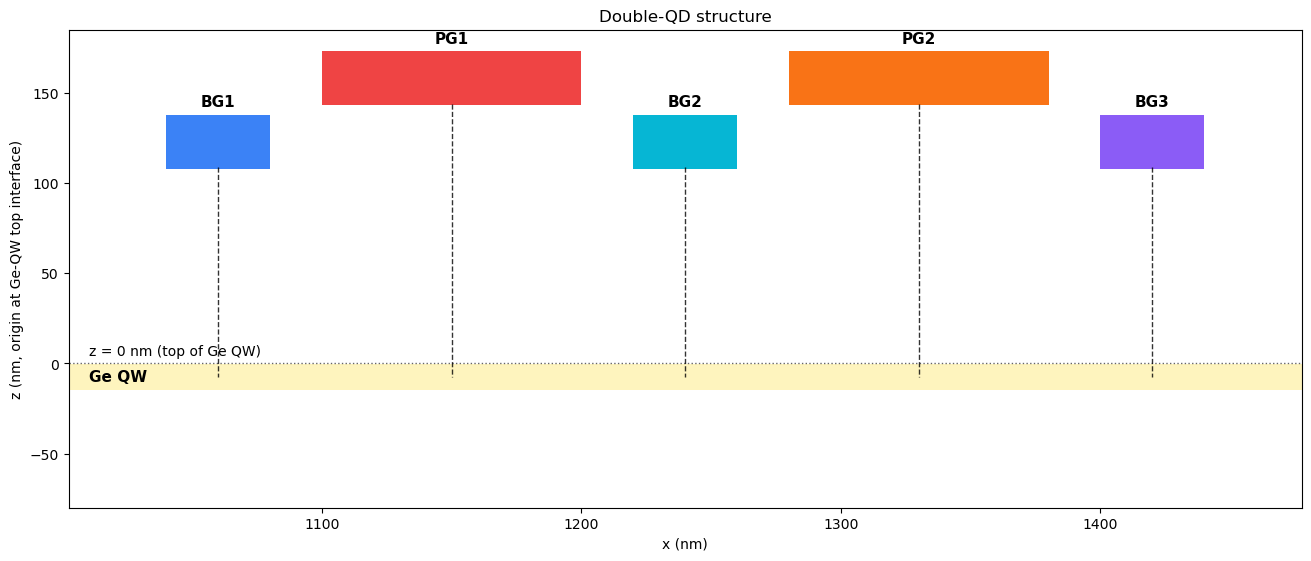

Double-QD gate order found in output: True
Gate sequence over the QW: BG1 -> PG1 -> BG2 -> PG2 -> BG3
Ge QW span from materials.fld: z = -14.8 to -0.2 nm
contact  x_left_nm  x_right_nm  x_center_nm  z_bottom_nm  z_top_nm
    BG1     1042.5      1077.5       1060.0        109.0     137.0
    PG1     1102.5      1197.5       1150.0        144.0     172.0
    BG2     1222.5      1257.5       1240.0        109.0     137.0
    PG2     1282.5      1377.5       1330.0        144.0     172.0
    BG3     1402.5      1437.5       1420.0        109.0     137.0


In [26]:
from matplotlib.colors import ListedColormap, BoundaryNorm

run_root = REPO_ROOT / "runs" / "Double_Quantum_Dot_2D"
structure = run_root / "Structure"

x, z, contacts = nna.load_fld_scalar(structure / "contacts.fld")
_, _, materials = nna.load_fld_scalar(structure / "materials.fld")

contacts = contacts.astype(int)
materials = materials.astype(int)

contact_names = {
    1: "BG1",
    2: "PG1",
    3: "BG2",
    4: "PG2",
    5: "BG3",
    6: "Source",
    7: "Drain",
    8: "Body",
}
active_ids = [1, 2, 3, 4, 5]

rows = []
for cid in active_ids:
    mask = contacts == cid
    iz, ix = np.where(mask)
    x_left, x_right = x[ix].min(), x[ix].max()
    z_bottom, z_top = z[iz].min(), z[iz].max()
    rows.append(
        {
            "contact": contact_names[cid],
            "x_left_nm": x_left,
            "x_right_nm": x_right,
            "x_center_nm": 0.5 * (x_left + x_right),
            "z_bottom_nm": z_bottom,
            "z_top_nm": z_top,
        }
    )

gate_df = pd.DataFrame(rows).sort_values("x_center_nm").reset_index(drop=True)
expected_order = ["BG1", "PG1", "BG2", "PG2", "BG3"]
order_ok = gate_df["contact"].tolist() == expected_order

gate_mask = np.isin(contacts, active_ids)
iz_gate, ix_gate = np.where(gate_mask)
xlim = (x[ix_gate].min() - 40, x[ix_gate].max() + 40)

ge_mask = materials == 8  # Ge
iz_ge, ix_ge = np.where(ge_mask)
z_ge_min, z_ge_max = z[iz_ge].min(), z[iz_ge].max()
z_ge_mid = 0.5 * (z_ge_min + z_ge_max)

cmap = ListedColormap(
    [
        "#ffffff",  # 0: none
        "#3b82f6",  # 1: BG1
        "#ef4444",  # 2: PG1
        "#06b6d4",  # 3: BG2
        "#f97316",  # 4: PG2
        "#8b5cf6",  # 5: BG3
        "#9ca3af",  # 6: Source
        "#6b7280",  # 7: Drain
        "#111827",  # 8: Body
    ]
)
norm = BoundaryNorm(np.arange(-0.5, 9.5, 1), cmap.N)

fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
ax.pcolormesh(x, z, contacts, shading="nearest", cmap=cmap, norm=norm)
ax.axhspan(z_ge_min, z_ge_max, color="#fde047", alpha=0.35, lw=0)

for row in gate_df.itertuples():
    ax.text(
        row.x_center_nm,
        row.z_top_nm + 4,
        row.contact,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
    ax.plot(
        [row.x_center_nm, row.x_center_nm],
        [row.z_bottom_nm, z_ge_mid],
        "--",
        color="k",
        lw=1,
        alpha=0.8,
    )

ax.axhline(0, color="k", ls=":", lw=1, alpha=0.6)
ax.text(xlim[0] + 8, 3, "z = 0 nm (top of Ge QW)", ha="left", va="bottom", fontsize=10)
ax.text(xlim[0] + 8, z_ge_mid, "Ge QW", ha="left", va="center", fontsize=11, fontweight="bold")

ax.set_xlim(*xlim)
ax.set_ylim(-80, 185)
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm, origin at Ge-QW top interface)")
ax.set_title("Double-QD structure")
ax.set_facecolor("white")
ax.grid(False)

plt.show()

print(f"Double-QD gate order found in output: {order_ok}")
print("Gate sequence over the QW:", " -> ".join(gate_df["contact"]))
print(f"Ge QW span from materials.fld: z = {z_ge_min:.1f} to {z_ge_max:.1f} nm")
print(gate_df.round(1).to_string(index=False))


### - Bandedges

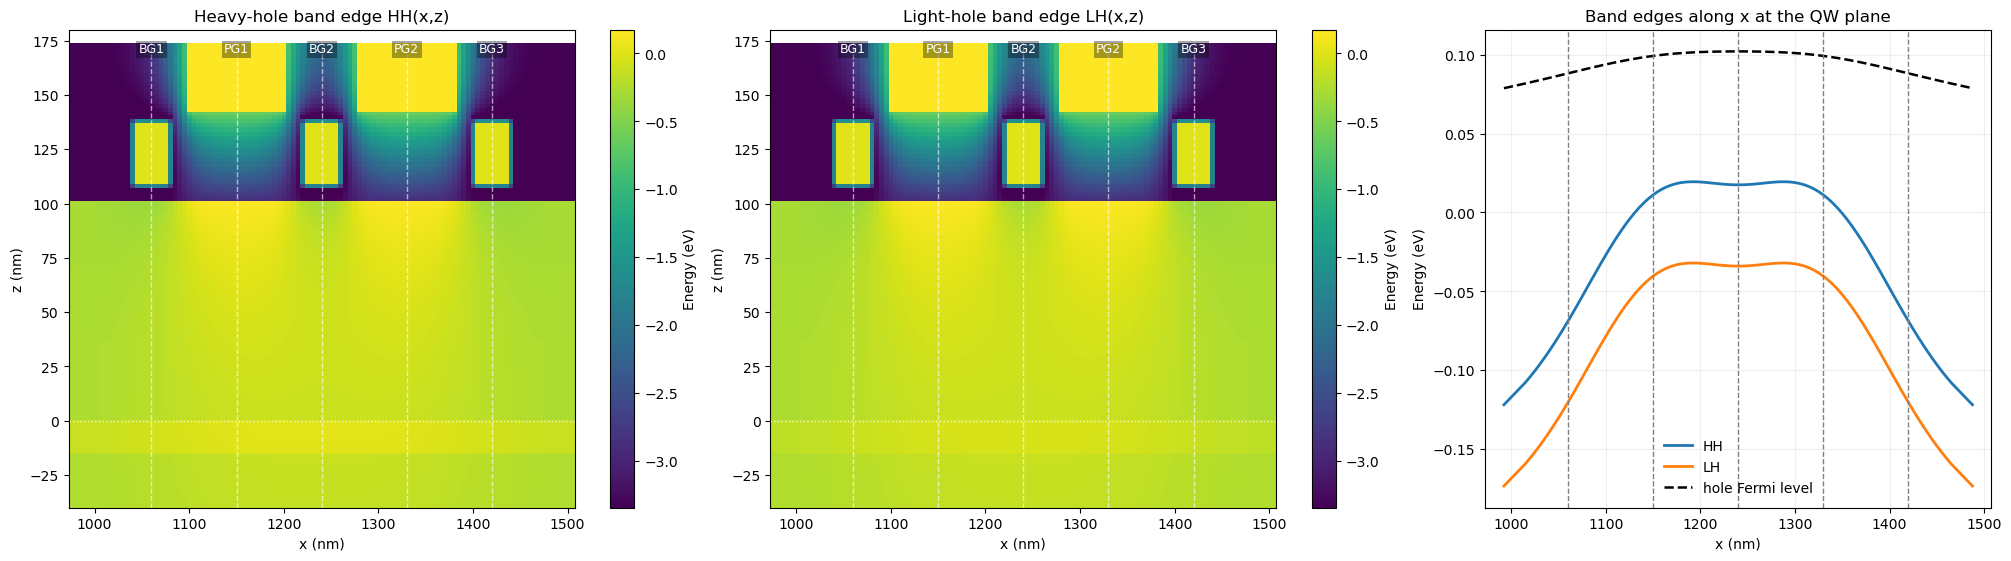

In [6]:
run_root = REPO_ROOT / "runs" / "Double_Quantum_Dot_2D"
bias0 = run_root / "bias_00000"
structure = run_root / "Structure"

# Gate positions from the structure output
xc, zc, contacts = nna.load_fld_scalar(structure / "contacts.fld")
contacts = contacts.astype(int)

contact_names = {1: "BG1", 2: "PG1", 3: "BG2", 4: "PG2", 5: "BG3"}
rows = []
for cid in [1, 2, 3, 4, 5]:
    mask = contacts == cid
    iz, ix = np.where(mask)
    rows.append(
        {
            "contact": contact_names[cid],
            "x_left_nm": xc[ix].min(),
            "x_right_nm": xc[ix].max(),
            "x_center_nm": 0.5 * (xc[ix].min() + xc[ix].max()),
        }
    )
gate_df = pd.DataFrame(rows).sort_values("x_center_nm").reset_index(drop=True)

xlim = (gate_df["x_left_nm"].min() - 70, gate_df["x_right_nm"].max() + 70)
zlim = (-40, 180)

# 2D band edges
x, z, hh_2d, _ = nna.load_fld_variable(bias0 / "bandedges.fld", 9)   # HH[eV]
_, _, lh_2d, _ = nna.load_fld_variable(bias0 / "bandedges.fld", 10)  # LH[eV]

# 1D line cut through the QW plane
band_x = nna.read_dat(bias0 / "bandedges_1d_x_QD.dat")
band_x = band_x[(band_x["x[nm]"] >= xlim[0]) & (band_x["x[nm]"] <= xlim[1])].copy()

# Common color scale in the zoomed window
ixw = (x >= xlim[0]) & (x <= xlim[1])
izw = (z >= zlim[0]) & (z <= zlim[1])
vals = np.concatenate([hh_2d[np.ix_(izw, ixw)].ravel(), lh_2d[np.ix_(izw, ixw)].ravel()])
vals = vals[np.isfinite(vals)]
vmin, vmax = np.percentile(vals, [2, 98])

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), constrained_layout=True)

for ax, Z, title in [
    (axes[0], hh_2d, "Heavy-hole band edge HH(x,z)"),
    (axes[1], lh_2d, "Light-hole band edge LH(x,z)"),
]:
    pcm = ax.pcolormesh(x, z, Z, shading="nearest", cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_xlim(*xlim)
    ax.set_ylim(*zlim)
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("z (nm)")
    ax.set_title(title)
    ax.axhline(0, color="w", ls=":", lw=1, alpha=0.8)
    for row in gate_df.itertuples():
        ax.axvline(row.x_center_nm, color="w", ls="--", lw=1, alpha=0.6)
        ax.text(
            row.x_center_nm,
            zlim[1] - 6,
            row.contact,
            ha="center",
            va="top",
            fontsize=9,
            color="white",
            bbox=dict(facecolor="black", alpha=0.35, pad=1.5, edgecolor="none"),
        )
    fig.colorbar(pcm, ax=ax, label="Energy (eV)")

ax = axes[2]
ax.plot(band_x["x[nm]"], band_x["HH[eV]"], lw=2, label="HH")
ax.plot(band_x["x[nm]"], band_x["LH[eV]"], lw=2, label="LH")
ax.plot(band_x["x[nm]"], band_x["hole_Fermi_level[eV]"], "k--", lw=1.8, label="hole Fermi level")
for row in gate_df.itertuples():
    ax.axvline(row.x_center_nm, color="0.5", ls="--", lw=1)
ax.set_xlim(*xlim)
ax.set_xlabel("x (nm)")
ax.set_ylabel("Energy (eV)")
ax.set_title("Band edges along x at the QW plane")
ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.show()


### - Carrier density

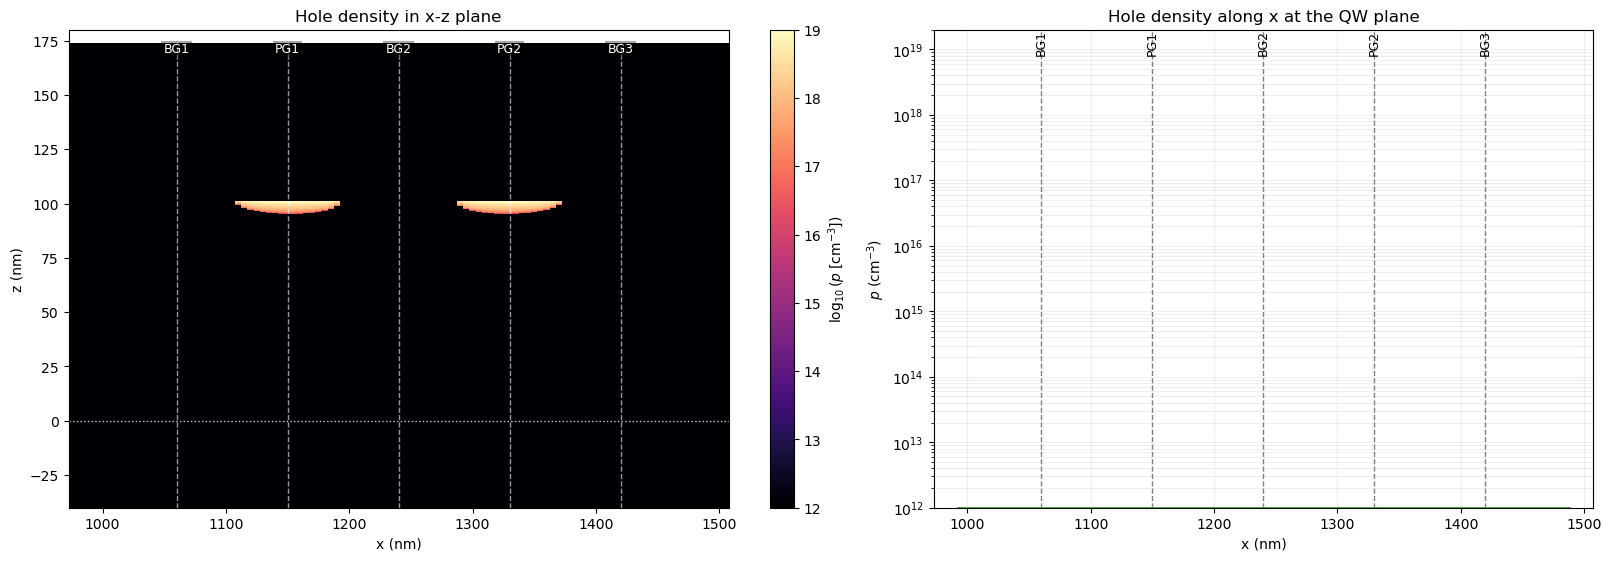

In [7]:
run_root = REPO_ROOT / "runs" / "Double_Quantum_Dot_2D"
bias0 = run_root / "bias_00000"
structure = run_root / "Structure"

# Gate positions from structure output
xc, zc, contacts = nna.load_fld_scalar(structure / "contacts.fld")
contacts = contacts.astype(int)

contact_names = {1: "BG1", 2: "PG1", 3: "BG2", 4: "PG2", 5: "BG3"}
rows = []
for cid in [1, 2, 3, 4, 5]:
    mask = contacts == cid
    iz, ix = np.where(mask)
    rows.append(
        {
            "contact": contact_names[cid],
            "x_left_nm": xc[ix].min(),
            "x_right_nm": xc[ix].max(),
            "x_center_nm": 0.5 * (xc[ix].min() + xc[ix].max()),
        }
    )
gate_df = pd.DataFrame(rows).sort_values("x_center_nm").reset_index(drop=True)

xlim = (gate_df["x_left_nm"].min() - 70, gate_df["x_right_nm"].max() + 70)
zlim = (-40, 180)

# 2D hole density
x, z, p2d = nna.load_fld_scalar(bias0 / "density_hole.fld")
p2d_cm3 = p2d * 1e18  # file units are 1e18 cm^-3

# 1D cut at the QW plane
p1d = nna.read_dat(bias0 / "density_hole_1d_x_QD.dat")
p1d = p1d[(p1d["x[nm]"] >= xlim[0]) & (p1d["x[nm]"] <= xlim[1])].copy()
p1d_cm3 = np.clip(p1d["Hole_density[1e18_cm^-3]"].to_numpy() * 1e18, 1e12, None)

# Log-scale view with a floor to suppress numerical underflow noise
floor_cm3 = 1e12
logp2d = np.log10(np.clip(p2d_cm3, floor_cm3, None))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True)

ax = axes[0]
pcm = ax.pcolormesh(x, z, logp2d, shading="nearest", cmap="magma", vmin=12, vmax=19)
ax.set_xlim(*xlim)
ax.set_ylim(*zlim)
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm)")
ax.set_title("Hole density in x-z plane")
ax.axhline(0, color="w", ls=":", lw=1, alpha=0.8)

for row in gate_df.itertuples():
    ax.axvline(row.x_center_nm, color="w", ls="--", lw=1, alpha=0.6)
    ax.text(
        row.x_center_nm,
        zlim[1] - 6,
        row.contact,
        ha="center",
        va="top",
        fontsize=9,
        color="white",
        bbox=dict(facecolor="black", alpha=0.35, pad=1.5, edgecolor="none"),
    )

fig.colorbar(pcm, ax=ax, label=r"$\log_{10}(p\;[\mathrm{cm}^{-3}])$")

ax = axes[1]
ax.semilogy(p1d["x[nm]"], p1d_cm3, lw=2, color="tab:green")
for row in gate_df.itertuples():
    ax.axvline(row.x_center_nm, color="0.5", ls="--", lw=1)
    ax.text(row.x_center_nm, 2e19, row.contact, ha="center", va="top", fontsize=9, rotation=90)

ax.set_xlim(*xlim)
ax.set_ylim(1e12, 2e19)
ax.set_xlabel("x (nm)")
ax.set_ylabel(r"$p$ (cm$^{-3}$)")
ax.set_title("Hole density along x at the QW plane")
ax.grid(alpha=0.2, which="both")

plt.show()


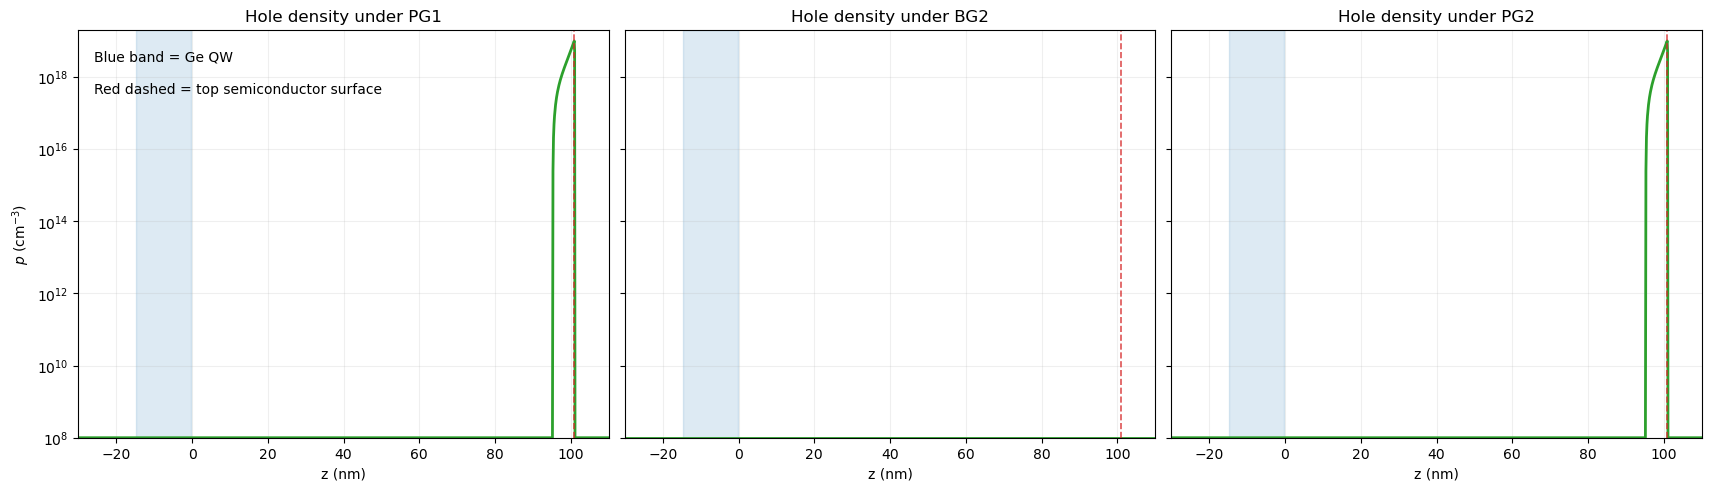

PG1: max p = 9.746e+18 cm^-3 at z = 100.90 nm
BG2: no physical hole accumulation in this cut (max is numerical noise at z = -4.50 nm)
PG2: max p = 9.746e+18 cm^-3 at z = 100.90 nm


In [8]:
run_root = REPO_ROOT / "runs" / "Double_Quantum_Dot_2D"
bias0 = run_root / "bias_00000"
structure = run_root / "Structure"

# Extract Ge QW span and top semiconductor surface from the structure output
_, z_mat, materials = nna.load_fld_scalar(structure / "materials.fld")
materials = materials.astype(int)

ge_mask = materials == 8
iz_ge, _ = np.where(ge_mask)
z_ge_min = z_mat[iz_ge].min()
z_ge_max = z_mat[iz_ge].max()

semi_mask = np.isin(materials, [8, 16])  # Ge + SiGe
iz_semi, _ = np.where(semi_mask)
z_semi_top = z_mat[iz_semi].max()

cuts = {
    "PG1": nna.read_dat(bias0 / "density_hole_1d_z_PG1.dat"),
    "BG2": nna.read_dat(bias0 / "density_hole_1d_z_BG2.dat"),
    "PG2": nna.read_dat(bias0 / "density_hole_1d_z_PG2.dat"),
}

floor_cm3 = 1e8
z_window = (-30, 110)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True, constrained_layout=True)

summary = []

for ax, (name, df) in zip(axes, cuts.items()):
    zcol = df.columns[0]
    pcol = df.columns[-1]

    zvals = df[zcol].to_numpy()
    p_cm3_raw = df[pcol].to_numpy() * 1e18
    p_cm3_plot = np.clip(p_cm3_raw, floor_cm3, None)

    imax = np.nanargmax(p_cm3_raw)
    summary.append((name, p_cm3_raw[imax], zvals[imax]))

    ax.semilogy(zvals, p_cm3_plot, lw=2, color="tab:green")
    ax.axvspan(z_ge_min, z_ge_max, color="tab:blue", alpha=0.15, label="Ge QW")
    ax.axvline(z_semi_top, color="tab:red", ls="--", lw=1.2, alpha=0.8)

    ax.set_xlim(*z_window)
    ax.set_ylim(1e8, 2e19)
    ax.set_xlabel("z (nm)")
    ax.set_title(f"Hole density under {name}")
    ax.grid(alpha=0.2, which="both")

axes[0].set_ylabel(r"$p$ (cm$^{-3}$)")
axes[0].text(0.03, 0.95, "Blue band = Ge QW", transform=axes[0].transAxes, va="top")
axes[0].text(0.03, 0.87, "Red dashed = top semiconductor surface", transform=axes[0].transAxes, va="top")

plt.show()

for name, pmax, zmax in summary:
    if pmax < 1e12:
        print(f"{name}: no physical hole accumulation in this cut (max is numerical noise at z = {zmax:.2f} nm)")
    else:
        print(f"{name}: max p = {pmax:.3e} cm^-3 at z = {zmax:.2f} nm")


### - Potential

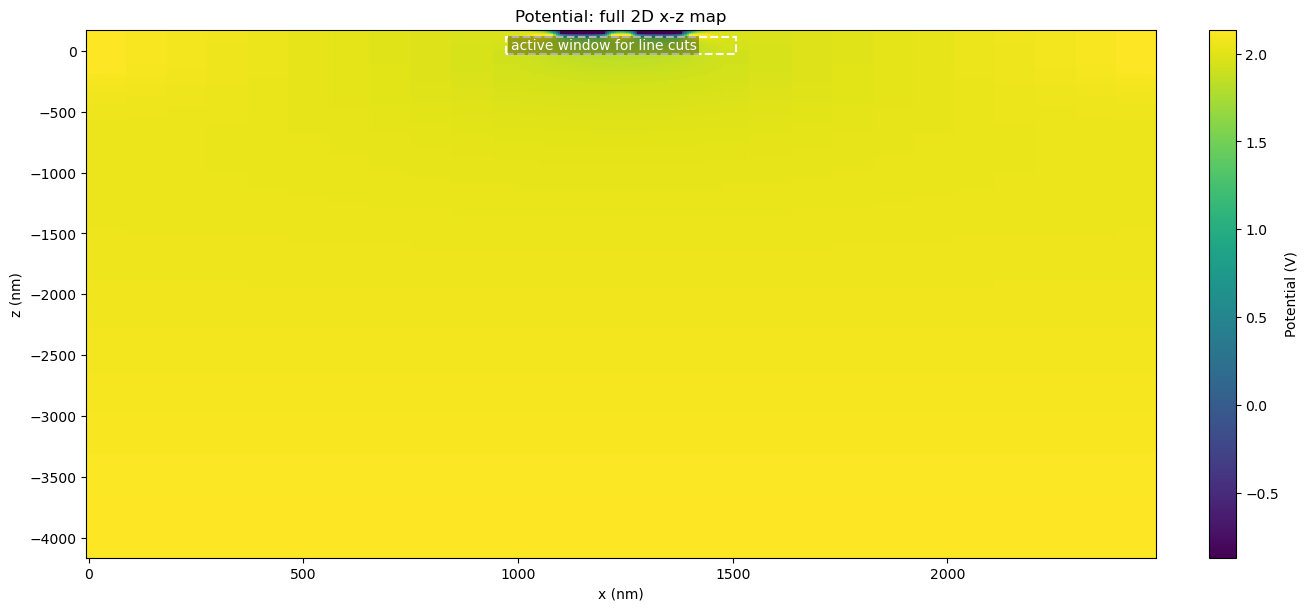

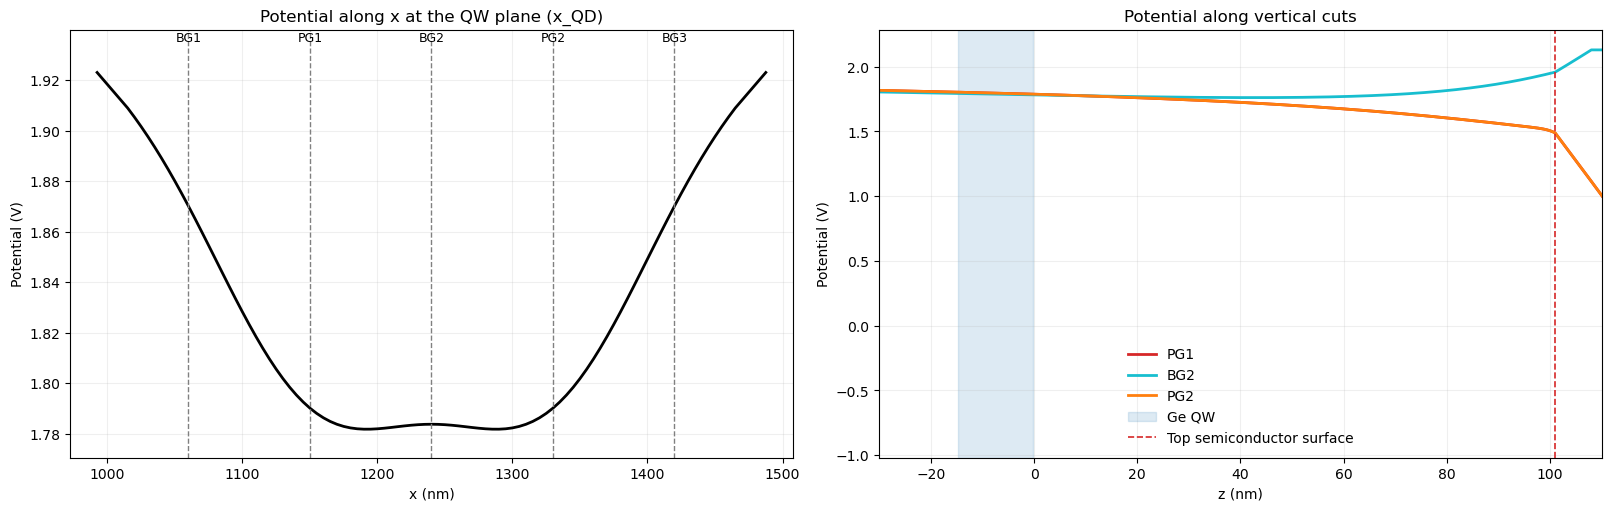

In [9]:
from matplotlib.patches import Rectangle

run_root = REPO_ROOT / "runs" / "Double_Quantum_Dot_2D"
bias0 = run_root / "bias_00000"
structure = run_root / "Structure"

# Gate positions from the structure output
xc, zc, contacts = nna.load_fld_scalar(structure / "contacts.fld")
contacts = contacts.astype(int)

contact_names = {1: "BG1", 2: "PG1", 3: "BG2", 4: "PG2", 5: "BG3"}
rows = []
for cid in [1, 2, 3, 4, 5]:
    mask = contacts == cid
    iz, ix = np.where(mask)
    rows.append(
        {
            "contact": contact_names[cid],
            "x_left_nm": xc[ix].min(),
            "x_right_nm": xc[ix].max(),
            "x_center_nm": 0.5 * (xc[ix].min() + xc[ix].max()),
        }
    )
gate_df = pd.DataFrame(rows).sort_values("x_center_nm").reset_index(drop=True)

x_window = (gate_df["x_left_nm"].min() - 70, gate_df["x_right_nm"].max() + 70)
z_window = (-30, 110)

# Ge QW span and top semiconductor surface from materials
_, z_mat, materials = nna.load_fld_scalar(structure / "materials.fld")
materials = materials.astype(int)

ge_mask = materials == 8
iz_ge, _ = np.where(ge_mask)
z_ge_min = z_mat[iz_ge].min()
z_ge_max = z_mat[iz_ge].max()

semi_mask = np.isin(materials, [8, 16])  # Ge + SiGe
iz_semi, _ = np.where(semi_mask)
z_semi_top = z_mat[iz_semi].max()

# --- Full 2D potential map ---
x, z, phi2d = nna.load_fld_scalar(bias0 / "potential.fld")

fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
pcm = ax.pcolormesh(x, z, phi2d, shading="nearest", cmap="viridis")
ax.set_title("Potential: full 2D x-z map")
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm)")

# Mark the active window used in the line plots
rect = Rectangle(
    (x_window[0], z_window[0]),
    x_window[1] - x_window[0],
    z_window[1] - z_window[0],
    fill=False,
    ec="white",
    lw=1.5,
    ls="--",
)
ax.add_patch(rect)
ax.text(
    x_window[0] + 10,
    z_window[1] - 8,
    "active window for line cuts",
    color="white",
    fontsize=10,
    ha="left",
    va="top",
    bbox=dict(facecolor="black", alpha=0.3, pad=2, edgecolor="none"),
)

fig.colorbar(pcm, ax=ax, label="Potential (V)")
plt.show()

# --- 1D line cuts ---
phi_x = nna.read_dat(bias0 / "potential_1d_x_QD.dat")
phi_x = phi_x[(phi_x["x[nm]"] >= x_window[0]) & (phi_x["x[nm]"] <= x_window[1])].copy()

cuts_z = {
    "PG1": nna.read_dat(bias0 / "potential_1d_z_PG1.dat"),
    "BG2": nna.read_dat(bias0 / "potential_1d_z_BG2.dat"),
    "PG2": nna.read_dat(bias0 / "potential_1d_z_PG2.dat"),
}
cut_colors = {"PG1": "tab:red", "BG2": "tab:cyan", "PG2": "tab:orange"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# x_QD cut
ax = axes[0]
ax.plot(phi_x["x[nm]"], phi_x["Potential[V]"], lw=2, color="black")
for row in gate_df.itertuples():
    ax.axvline(row.x_center_nm, color="0.5", ls="--", lw=1)
ymin, ymax = phi_x["Potential[V]"].min(), phi_x["Potential[V]"].max()
dy = ymax - ymin
ax.set_ylim(ymin - 0.08 * dy, ymax + 0.12 * dy)
for row in gate_df.itertuples():
    ax.text(row.x_center_nm, ymax + 0.08 * dy, row.contact, ha="center", va="bottom", fontsize=9)
ax.set_xlim(*x_window)
ax.set_xlabel("x (nm)")
ax.set_ylabel("Potential (V)")
ax.set_title("Potential along x at the QW plane (x_QD)")
ax.grid(alpha=0.2)

# Vertical cuts
ax = axes[1]
for name, df in cuts_z.items():
    ax.plot(df["y[nm]"], df["Potential[V]"], lw=2, label=name, color=cut_colors[name])

ax.axvspan(z_ge_min, z_ge_max, color="tab:blue", alpha=0.15, label="Ge QW")
ax.axvline(z_semi_top, color="tab:red", ls="--", lw=1.2, label="Top semiconductor surface")

ax.set_xlim(*z_window)
ax.set_xlabel("z (nm)")
ax.set_ylabel("Potential (V)")
ax.set_title("Potential along vertical cuts")
ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.show()


## 2. 3D Simulation

In [14]:
inp = nna.run_input(INPUT_DOUBLE_DOT_3D)
print("Output folder:", inp.folder_output)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_3D --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/robert_inputs/double_qd/3d/Double_Quantum_Dot_3D.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                                                             
The terms of copyright of the nextnano++ code and o

In [15]:
run_root = Path(inp.folder_output)
rp = nna.get_run_paths(run_root)
structure = rp.structure
bias0 = rp.bias0()

print("Run root   :", run_root)
print("Structure  :", structure)
print("Bias0      :", bias0)

Run root   : /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_3D
Structure  : /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_3D/Structure
Bias0      : /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_3D/bias_00000


### - Structure Check

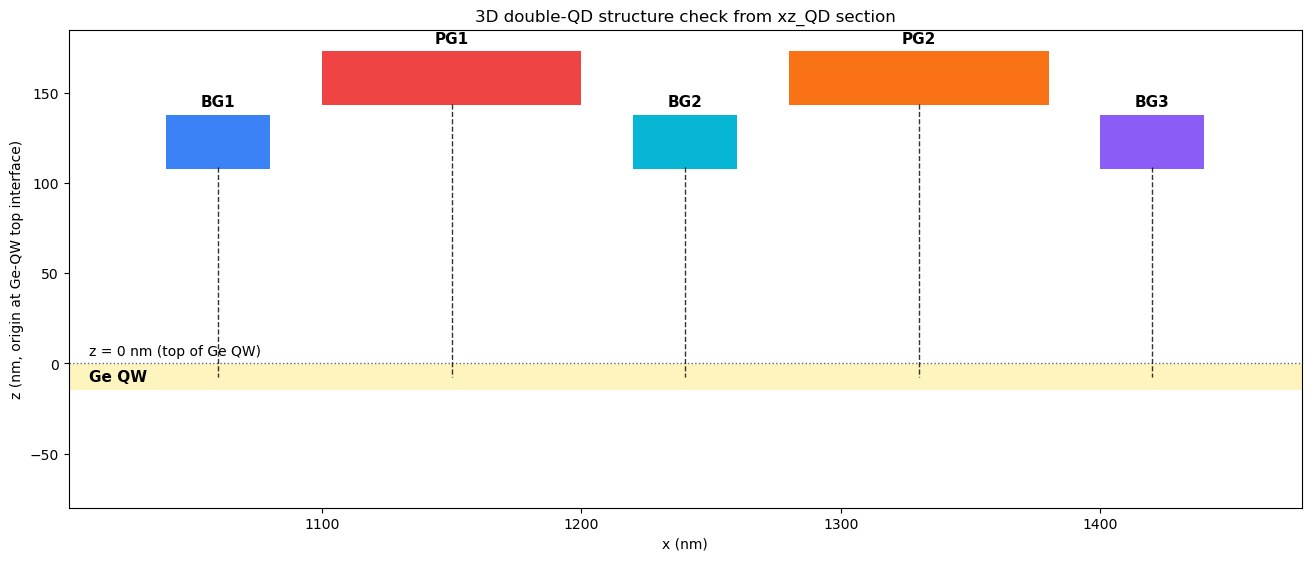

Double-QD gate order found in output: True
Gate sequence over the QW: BG1 -> PG1 -> BG2 -> PG2 -> BG3
Ge QW span from materials section: z = -14.8 to -0.2 nm
contact  x_left_nm  x_right_nm  x_center_nm  z_bottom_nm  z_top_nm
    BG1     1042.5      1077.5       1060.0        109.0     137.0
    PG1     1102.5      1197.5       1150.0        144.0     172.0
    BG2     1222.5      1257.5       1240.0        109.0     137.0
    PG2     1282.5      1377.5       1330.0        144.0     172.0
    BG3     1402.5      1437.5       1420.0        109.0     137.0


In [17]:
# xz section through the center line of the device
contacts_xz_path = section_fld(structure, "contacts", "xz_QD")
materials_xz_path = section_fld(structure, "materials", "xz_QD")

x, z, contacts_xz = nna.load_fld_scalar(contacts_xz_path)
_, _, materials_xz = nna.load_fld_scalar(materials_xz_path)

contacts_xz = contacts_xz.astype(int)
materials_xz = materials_xz.astype(int)

contact_names = {
    1: "BG1",
    2: "PG1",
    3: "BG2",
    4: "PG2",
    5: "BG3",
    6: "Source",
    7: "Drain",
    8: "Body",
}
active_ids = [1, 2, 3, 4, 5]

rows = []
for cid in active_ids:
    mask = contacts_xz == cid
    iz, ix = np.where(mask)
    x_left, x_right = x[ix].min(), x[ix].max()
    z_bottom, z_top = z[iz].min(), z[iz].max()
    rows.append(
        {
            "contact": contact_names[cid],
            "x_left_nm": x_left,
            "x_right_nm": x_right,
            "x_center_nm": 0.5 * (x_left + x_right),
            "z_bottom_nm": z_bottom,
            "z_top_nm": z_top,
        }
    )

gate_df = pd.DataFrame(rows).sort_values("x_center_nm").reset_index(drop=True)
expected_order = ["BG1", "PG1", "BG2", "PG2", "BG3"]
order_ok = gate_df["contact"].tolist() == expected_order

gate_mask = np.isin(contacts_xz, active_ids)
iz_gate, ix_gate = np.where(gate_mask)
xlim = (x[ix_gate].min() - 40, x[ix_gate].max() + 40)

# Ge / semiconductor spans from materials
ge_mask = materials_xz == 8
iz_ge, ix_ge = np.where(ge_mask)
z_ge_min, z_ge_max = z[iz_ge].min(), z[iz_ge].max()
z_ge_mid = 0.5 * (z_ge_min + z_ge_max)

semi_mask = np.isin(materials_xz, [8, 16])  # Ge + SiGe
iz_semi, _ = np.where(semi_mask)
z_semi_top = z[iz_semi].max()

cmap = ListedColormap(
    [
        "#ffffff",  # 0: none
        "#3b82f6",  # 1: BG1
        "#ef4444",  # 2: PG1
        "#06b6d4",  # 3: BG2
        "#f97316",  # 4: PG2
        "#8b5cf6",  # 5: BG3
        "#9ca3af",  # 6: Source
        "#6b7280",  # 7: Drain
        "#111827",  # 8: Body
    ]
)
norm = BoundaryNorm(np.arange(-0.5, 9.5, 1), cmap.N)

fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
ax.pcolormesh(x, z, contacts_xz, shading="nearest", cmap=cmap, norm=norm)
ax.axhspan(z_ge_min, z_ge_max, color="#fde047", alpha=0.35, lw=0)

for row in gate_df.itertuples():
    ax.text(
        row.x_center_nm,
        row.z_top_nm + 4,
        row.contact,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
    ax.plot(
        [row.x_center_nm, row.x_center_nm],
        [row.z_bottom_nm, z_ge_mid],
        "--",
        color="k",
        lw=1,
        alpha=0.8,
    )

ax.axhline(0, color="k", ls=":", lw=1, alpha=0.6)
ax.text(xlim[0] + 8, 3, "z = 0 nm (top of Ge QW)", ha="left", va="bottom", fontsize=10)
ax.text(xlim[0] + 8, z_ge_mid, "Ge QW", ha="left", va="center", fontsize=11, fontweight="bold")

ax.set_xlim(*xlim)
ax.set_ylim(-80, 185)
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm, origin at Ge-QW top interface)")
ax.set_title("3D double-QD structure check from xz_QD section")
ax.set_facecolor("white")
ax.grid(False)

plt.show()

print(f"Double-QD gate order found in output: {order_ok}")
print("Gate sequence over the QW:", " -> ".join(gate_df["contact"]))
print(f"Ge QW span from materials section: z = {z_ge_min:.1f} to {z_ge_max:.1f} nm")
print(gate_df.round(1).to_string(index=False))

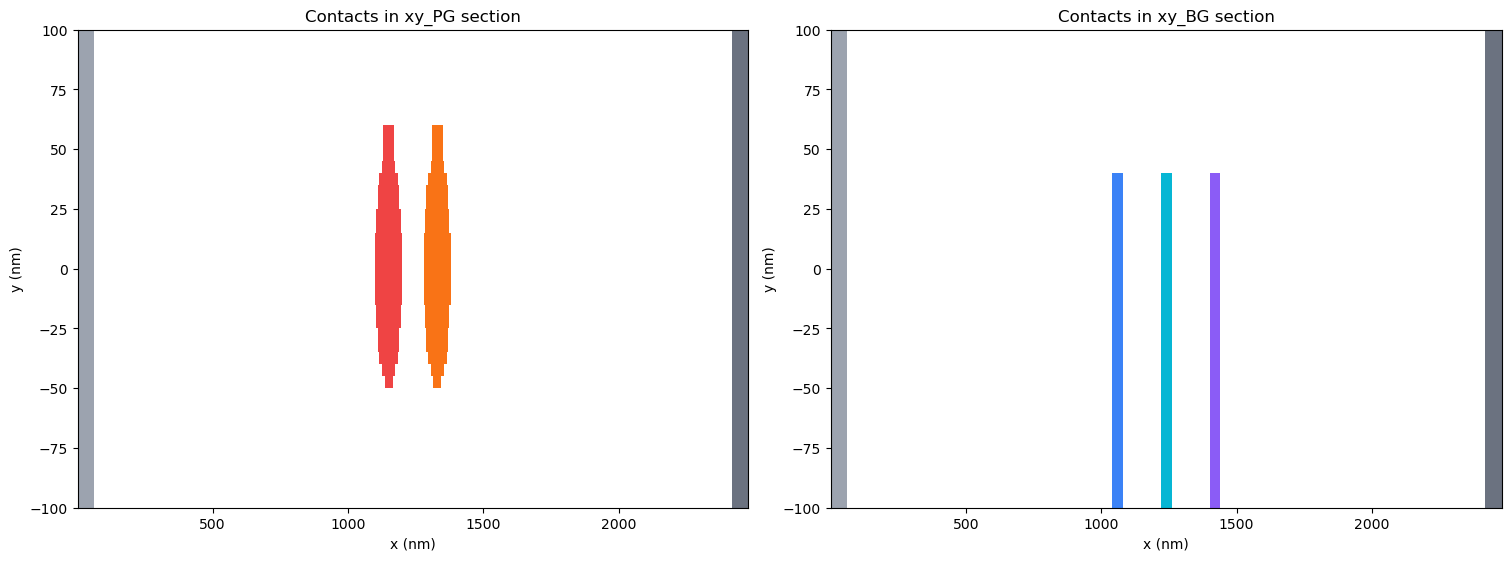

In [18]:
try:
    x_pg, y_pg, contacts_xy_pg = nna.load_fld_scalar(section_fld(structure, "contacts", "xy_PG"))
    x_bg, y_bg, contacts_xy_bg = nna.load_fld_scalar(section_fld(structure, "contacts", "xy_BG"))

    contacts_xy_pg = contacts_xy_pg.astype(int)
    contacts_xy_bg = contacts_xy_bg.astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

    axes[0].pcolormesh(x_pg, y_pg, contacts_xy_pg, shading="nearest", cmap=cmap, norm=norm)
    axes[0].set_title("Contacts in xy_PG section")
    axes[0].set_xlabel("x (nm)")
    axes[0].set_ylabel("y (nm)")

    axes[1].pcolormesh(x_bg, y_bg, contacts_xy_bg, shading="nearest", cmap=cmap, norm=norm)
    axes[1].set_title("Contacts in xy_BG section")
    axes[1].set_xlabel("x (nm)")
    axes[1].set_ylabel("y (nm)")

    plt.show()

except FileNotFoundError as e:
    print("Skipping xy_PG / xy_BG top-view check:")
    print(e)

### - Bandedges

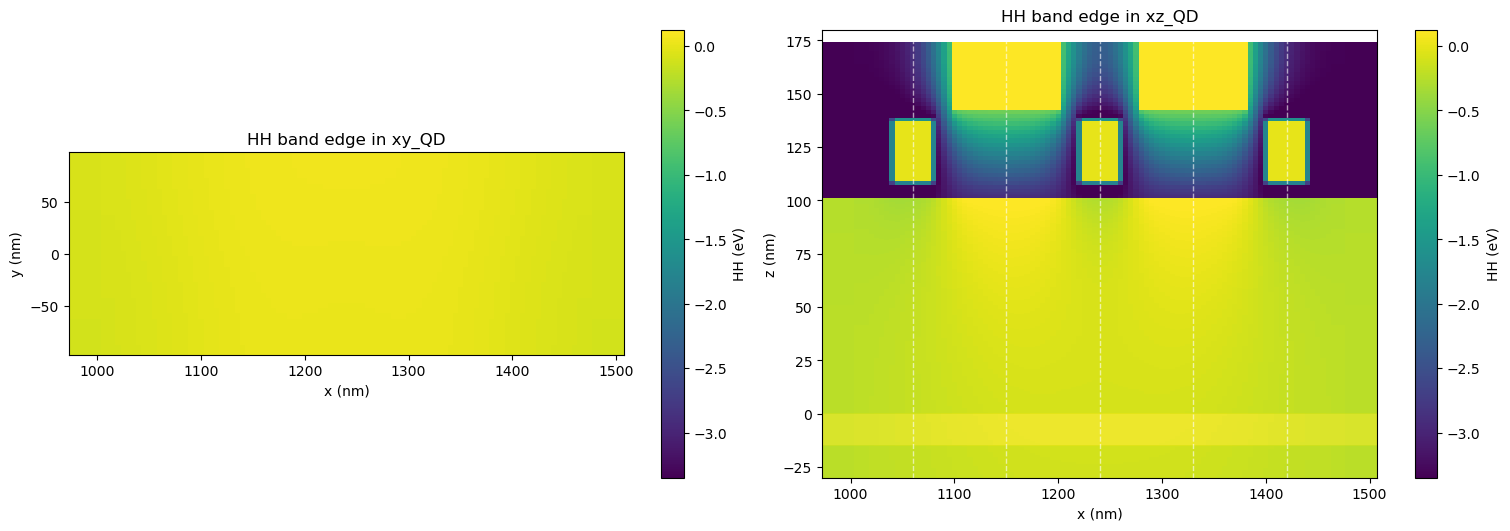

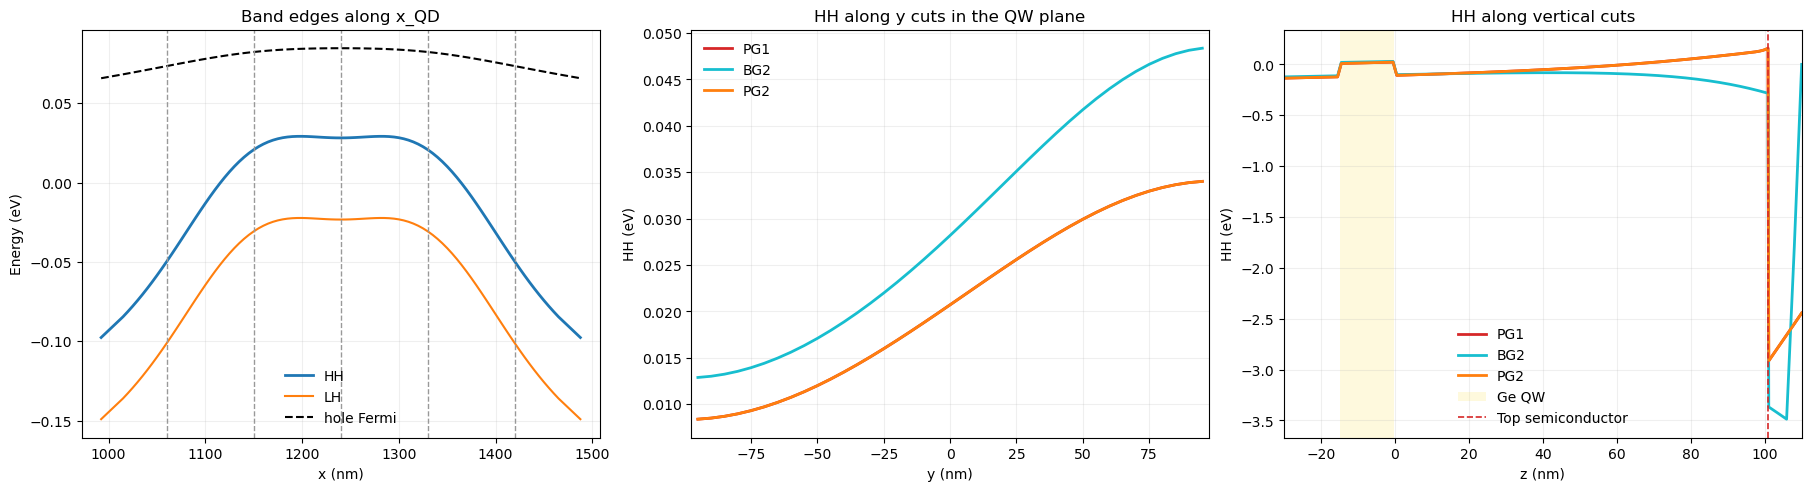

In [ ]:
x_xy, y_xy, hh_xy = load_var2d(BIAS3D / "bandedges_2d_xy_QD.fld", "HH[eV]")
x_xz, z_xz, hh_xz = load_var2d(BIAS3D / "bandedges_2d_xz_QD.fld", "HH[eV]")

vals = np.concatenate([hh_xy.ravel(), hh_xz.ravel()])
vals = vals[np.isfinite(vals) & (vals != 0)]
vmin, vmax = np.percentile(vals, [2, 98])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), constrained_layout=True)

pcm = axes[0].pcolormesh(x_xy, y_xy, hh_xy, shading="nearest", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_xlim(*XWIN3D)
axes[0].set_ylim(*YWIN3D)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")
axes[0].set_title("HH band edge in xy_QD")
fig.colorbar(pcm, ax=axes[0], label="HH (eV)")

pcm = axes[1].pcolormesh(x_xz, z_xz, hh_xz, shading="nearest", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].axhspan(*ZQW3D, color="white", alpha=0.08, lw=0)
for row in GATES3D.itertuples():
    axes[1].axvline(row.x_center_nm, color="white", ls="--", lw=1, alpha=0.6)
axes[1].set_xlim(*XWIN3D)
axes[1].set_ylim(*ZWIN3D)
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("z (nm)")
axes[1].set_title("HH band edge in xz_QD")
fig.colorbar(pcm, ax=axes[1], label="HH (eV)")

plt.show()

bx = crop_df(nna.read_dat(BIAS3D / "bandedges_1d_x_QD.dat"), XWIN3D)
bys = {k: crop_df(nna.read_dat(BIAS3D / f"bandedges_1d_y_{k}.dat"), YWIN3D) for k in CUT_COLORS}
bzs = {k: crop_df(nna.read_dat(BIAS3D / f"bandedges_1d_z_{k}.dat"), ZLINE3D) for k in CUT_COLORS}

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

axes[0].plot(bx["x[nm]"], bx["HH[eV]"], lw=2, label="HH")
axes[0].plot(bx["x[nm]"], bx["LH[eV]"], lw=1.5, label="LH")
axes[0].plot(bx["x[nm]"], bx["hole_Fermi_level[eV]"], "k--", lw=1.5, label="hole Fermi")
for row in GATES3D.itertuples():
    axes[0].axvline(row.x_center_nm, color="0.6", ls="--", lw=1)
axes[0].set_xlim(*XWIN3D)
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("Energy (eV)")
axes[0].set_title("Band edges along x_QD")
axes[0].grid(alpha=0.2)
axes[0].legend(frameon=False)

for name, df in bys.items():
    axes[1].plot(df["y[nm]"], df["HH[eV]"], lw=2, label=name, color=CUT_COLORS[name])
axes[1].set_xlim(*YWIN3D)
axes[1].set_xlabel("y (nm)")
axes[1].set_ylabel("HH (eV)")
axes[1].set_title("HH along y cuts in the QW plane")
axes[1].grid(alpha=0.2)
axes[1].legend(frameon=False)

for name, df in bzs.items():
    axes[2].plot(df["z[nm]"], df["HH[eV]"], lw=2, label=name, color=CUT_COLORS[name])
axes[2].axvspan(*ZQW3D, color="#fde047", alpha=0.18, lw=0, label="Ge QW")
axes[2].axvline(ZSEMI_TOP3D, color="tab:red", ls="--", lw=1.2, label="Top semiconductor")
axes[2].set_xlim(*ZLINE3D)
axes[2].set_xlabel("z (nm)")
axes[2].set_ylabel("HH (eV)")
axes[2].set_title("HH along vertical cuts")
axes[2].grid(alpha=0.2)
axes[2].legend(frameon=False)

plt.show()


### - Carrier density

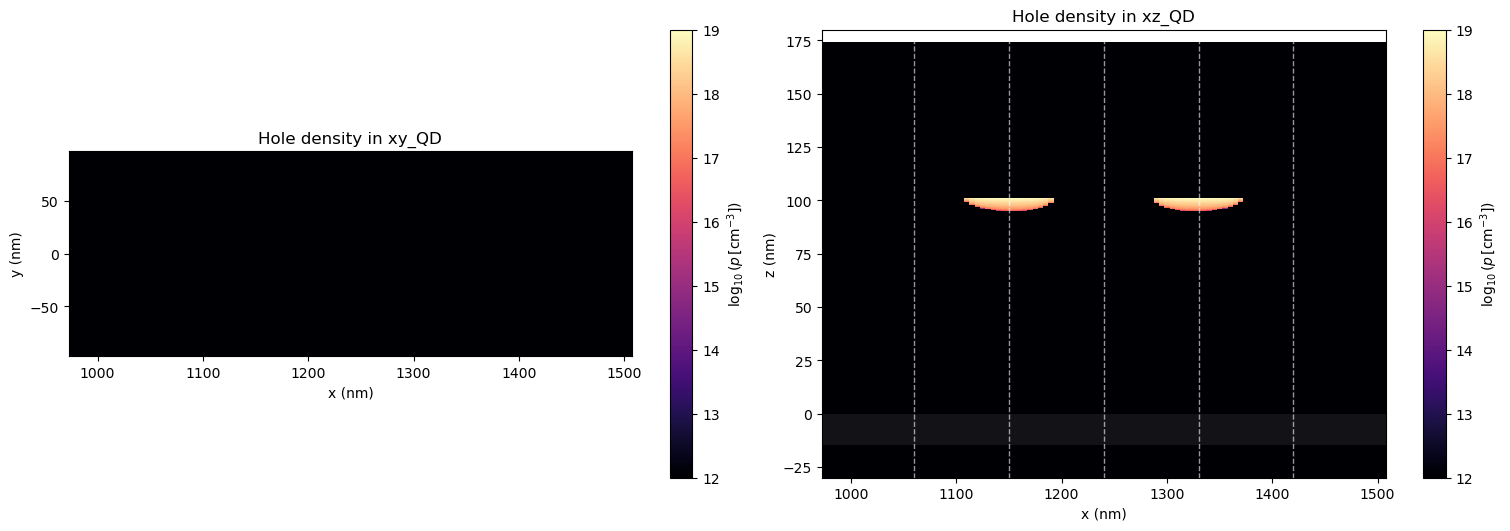

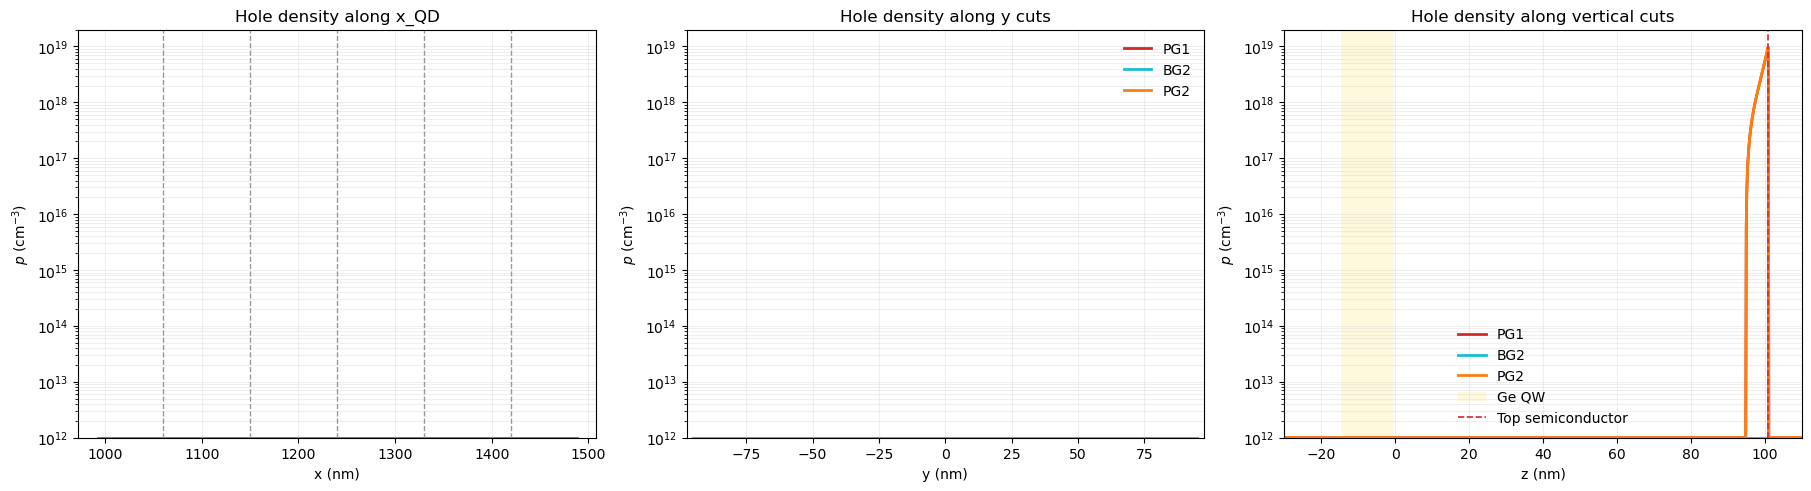

In [24]:
floor_cm3 = 1e12

x_xy, y_xy, p_xy = load_scalar2d(BIAS3D / "density_hole_2d_xy_QD.fld")
x_xz, z_xz, p_xz = load_scalar2d(BIAS3D / "density_hole_2d_xz_QD.fld")

logp_xy = np.log10(np.clip(p_xy * 1e18, floor_cm3, None))
logp_xz = np.log10(np.clip(p_xz * 1e18, floor_cm3, None))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), constrained_layout=True)

pcm = axes[0].pcolormesh(x_xy, y_xy, logp_xy, shading="nearest", cmap="magma", vmin=12, vmax=19)
axes[0].set_xlim(*XWIN3D)
axes[0].set_ylim(*YWIN3D)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")
axes[0].set_title("Hole density in xy_QD")
fig.colorbar(pcm, ax=axes[0], label=r"$\log_{10}(p\,[\mathrm{cm}^{-3}])$")

pcm = axes[1].pcolormesh(x_xz, z_xz, logp_xz, shading="nearest", cmap="magma", vmin=12, vmax=19)
axes[1].axhspan(*ZQW3D, color="white", alpha=0.08, lw=0)
for row in GATES3D.itertuples():
    axes[1].axvline(row.x_center_nm, color="white", ls="--", lw=1, alpha=0.6)
axes[1].set_xlim(*XWIN3D)
axes[1].set_ylim(*ZWIN3D)
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("z (nm)")
axes[1].set_title("Hole density in xz_QD")
fig.colorbar(pcm, ax=axes[1], label=r"$\log_{10}(p\,[\mathrm{cm}^{-3}])$")

plt.show()

px = crop_df(nna.read_dat(BIAS3D / "density_hole_1d_x_QD.dat"), XWIN3D)
pys = {k: crop_df(nna.read_dat(BIAS3D / f"density_hole_1d_y_{k}.dat"), YWIN3D) for k in CUT_COLORS}
pzs = {k: crop_df(nna.read_dat(BIAS3D / f"density_hole_1d_z_{k}.dat"), ZLINE3D) for k in CUT_COLORS}

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

axes[0].semilogy(px["x[nm]"], np.clip(px["Hole_density[1e18_cm^-3]"] * 1e18, floor_cm3, None), lw=2, color="tab:green")
for row in GATES3D.itertuples():
    axes[0].axvline(row.x_center_nm, color="0.6", ls="--", lw=1)
axes[0].set_xlim(*XWIN3D)
axes[0].set_ylim(floor_cm3, 2e19)
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel(r"$p$ (cm$^{-3}$)")
axes[0].set_title("Hole density along x_QD")
axes[0].grid(alpha=0.2, which="both")

for name, df in pys.items():
    axes[1].semilogy(df["y[nm]"], np.clip(df["Hole_density[1e18_cm^-3]"] * 1e18, floor_cm3, None),
                     lw=2, label=name, color=CUT_COLORS[name])
axes[1].set_xlim(*YWIN3D)
axes[1].set_ylim(floor_cm3, 2e19)
axes[1].set_xlabel("y (nm)")
axes[1].set_ylabel(r"$p$ (cm$^{-3}$)")
axes[1].set_title("Hole density along y cuts")
axes[1].grid(alpha=0.2, which="both")
axes[1].legend(frameon=False)

for name, df in pzs.items():
    axes[2].semilogy(df["z[nm]"], np.clip(df["Hole_density[1e18_cm^-3]"] * 1e18, floor_cm3, None),
                     lw=2, label=name, color=CUT_COLORS[name])
axes[2].axvspan(*ZQW3D, color="#fde047", alpha=0.18, lw=0, label="Ge QW")
axes[2].axvline(ZSEMI_TOP3D, color="tab:red", ls="--", lw=1.2, label="Top semiconductor")
axes[2].set_xlim(*ZLINE3D)
axes[2].set_ylim(floor_cm3, 2e19)
axes[2].set_xlabel("z (nm)")
axes[2].set_ylabel(r"$p$ (cm$^{-3}$)")
axes[2].set_title("Hole density along vertical cuts")
axes[2].grid(alpha=0.2, which="both")
axes[2].legend(frameon=False)

plt.show()


### - Potential

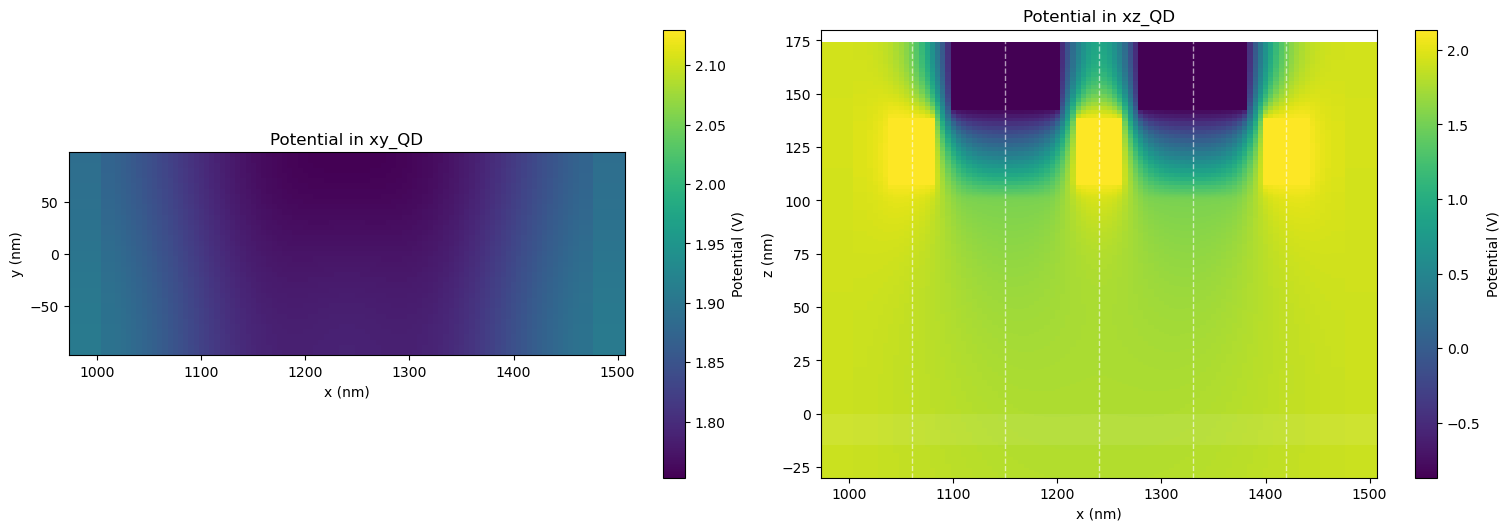

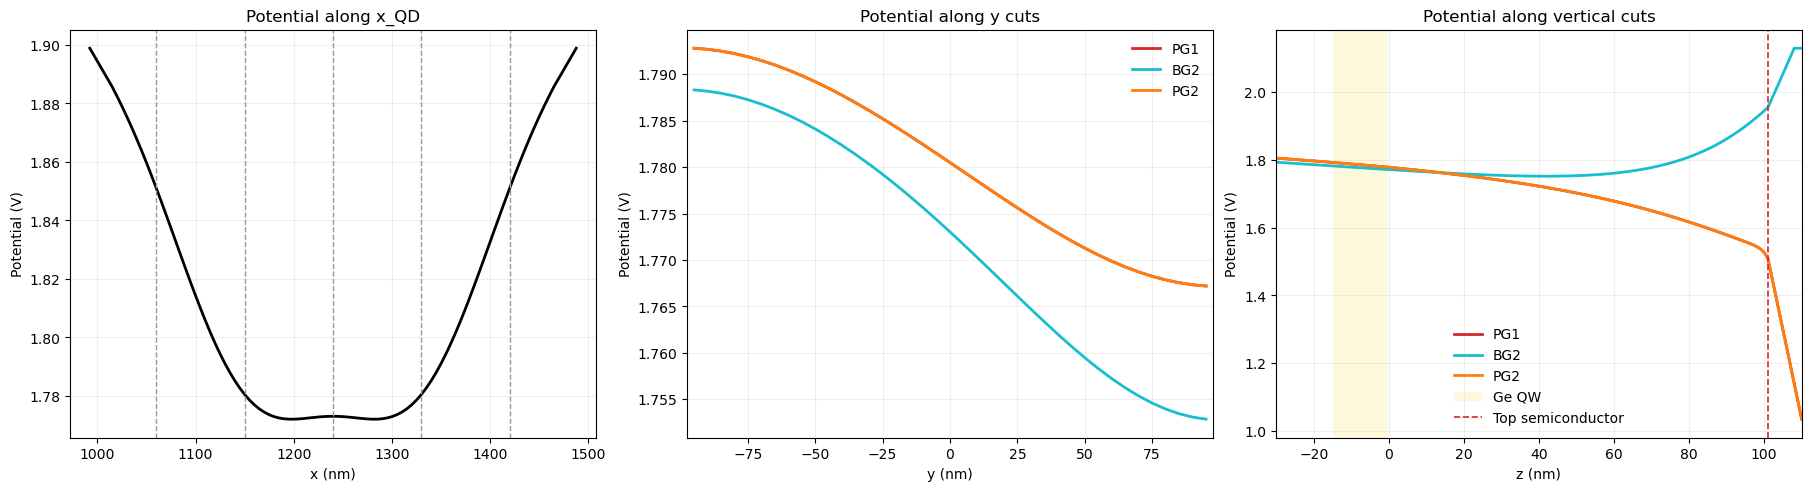

In [25]:
x_xy, y_xy, phi_xy = load_scalar2d(BIAS3D / "potential_2d_xy_QD.fld")
x_xz, z_xz, phi_xz = load_scalar2d(BIAS3D / "potential_2d_xz_QD.fld")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), constrained_layout=True)

pcm = axes[0].pcolormesh(x_xy, y_xy, phi_xy, shading="nearest", cmap="viridis")
axes[0].set_xlim(*XWIN3D)
axes[0].set_ylim(*YWIN3D)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")
axes[0].set_title("Potential in xy_QD")
fig.colorbar(pcm, ax=axes[0], label="Potential (V)")

pcm = axes[1].pcolormesh(x_xz, z_xz, phi_xz, shading="nearest", cmap="viridis")
axes[1].axhspan(*ZQW3D, color="white", alpha=0.08, lw=0)
for row in GATES3D.itertuples():
    axes[1].axvline(row.x_center_nm, color="white", ls="--", lw=1, alpha=0.6)
axes[1].set_xlim(*XWIN3D)
axes[1].set_ylim(*ZWIN3D)
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("z (nm)")
axes[1].set_title("Potential in xz_QD")
fig.colorbar(pcm, ax=axes[1], label="Potential (V)")

plt.show()

vx = crop_df(nna.read_dat(BIAS3D / "potential_1d_x_QD.dat"), XWIN3D)
vys = {k: crop_df(nna.read_dat(BIAS3D / f"potential_1d_y_{k}.dat"), YWIN3D) for k in CUT_COLORS}
vzs = {k: crop_df(nna.read_dat(BIAS3D / f"potential_1d_z_{k}.dat"), ZLINE3D) for k in CUT_COLORS}

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

axes[0].plot(vx["x[nm]"], vx["Potential[V]"], lw=2, color="black")
for row in GATES3D.itertuples():
    axes[0].axvline(row.x_center_nm, color="0.6", ls="--", lw=1)
axes[0].set_xlim(*XWIN3D)
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("Potential (V)")
axes[0].set_title("Potential along x_QD")
axes[0].grid(alpha=0.2)

for name, df in vys.items():
    axes[1].plot(df["y[nm]"], df["Potential[V]"], lw=2, label=name, color=CUT_COLORS[name])
axes[1].set_xlim(*YWIN3D)
axes[1].set_xlabel("y (nm)")
axes[1].set_ylabel("Potential (V)")
axes[1].set_title("Potential along y cuts")
axes[1].grid(alpha=0.2)
axes[1].legend(frameon=False)

for name, df in vzs.items():
    axes[2].plot(df["z[nm]"], df["Potential[V]"], lw=2, label=name, color=CUT_COLORS[name])
axes[2].axvspan(*ZQW3D, color="#fde047", alpha=0.18, lw=0, label="Ge QW")
axes[2].axvline(ZSEMI_TOP3D, color="tab:red", ls="--", lw=1.2, label="Top semiconductor")
axes[2].set_xlim(*ZLINE3D)
axes[2].set_xlabel("z (nm)")
axes[2].set_ylabel("Potential (V)")
axes[2].set_title("Potential along vertical cuts")
axes[2].grid(alpha=0.2)
axes[2].legend(frameon=False)

plt.show()
